# Sea-Ice Model Package (SPyIce)

The SPyIce package is a software tool that enables 1D finite difference simulation for vertical transport equations. It specifically focuses on thermal diffusion with the influence of salinity and physical properties. The package utilizes the Thomas tridiagonal solver as the solver algorithm. With SPyIce, users can model and analyze the behavior of temperature, salinity, and other relevant variables in a vertical system. It provides a comprehensive framework for studying the thermal diffusion process and its interaction with salinity in various scenarios. Hydra is used to automate the simulation runs of the Sea-Ice Model. It is used to manage and run sea ice simulations, making it easier for users to explore different scenarios and optimize their models.

## Package Demo Example 1: Without Hydra

#### Import Packages

In [1]:
import os
from pathlib import Path
import matplotlib.pyplot as plt
from datetime import datetime

%matplotlib inline
from omegaconf import OmegaConf

from spyice.utils import create_output_directory
from spyice.postprocess import Analysis, VisualiseModel
from spyice.utils import ConfigSort
from spyice.models import SeaIceModel
from spyice.preprocess import PreProcess

#### Define Inputs and Project Output paths

In [2]:
# creates a OmegaConf object from a dictionary for fast testing only for parameters: constants, dt, S_IC, iter_max, dz
constants_dict = {
    "constants": {"constants": "real"},
    "dt": {"dt": 47},
    "S_IC": {"S_IC": "S34"},
    "iter_max": {"iter_max": 1500},
    "dz": {"dz": 0.01},
}
config_raw = OmegaConf.create(constants_dict)
config = ConfigSort.getconfig_dataclass(config_raw, config_type="jupyter")

base_dir = Path.cwd()
output_base_dir = Path(base_dir, "output")
# Current date-time string
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
output_base_dir = Path(output_base_dir, timestamp)
wo_hydra_dir = Path(output_base_dir, "without_hydra")
out_dir_final = create_output_directory(wo_hydra_dir, config.initial_salinity.S_IC, "2", "0.01", "47", "1000", "example")

### Preprocessing 

In [3]:
# preprocess the data
preprocess_data, userinput_data = PreProcess.get_variables(config_raw, out_dir_final)

Preprocessing...
User Configuration Data Setup Complete...
Geometry Data Setup Complete...
Results Data Setup Complete...
Time step set to: 47s
Applied Initial & Boundary Conditions...
Preprocessing done.


### Model settings

for more info on all the model parameters have a look at the documentation: [userinput](https://starry-phoenix.github.io/spyice-thesis/build/html/api/spyice.parameters.user_input.html)

In [4]:
from spyice.parameters import Constants

# Choose between real and test constants
constants = Constants.REAL.value

##### Model settings: Model type choose between ->
- Algae model 
- Algae model type : Multiple layers or Single layer 
- Radiation model
- Only diffusion model (without advection)
- Salinity Model

In [ ]:
# change user input data 
userinput_data.is_diffusiononly_equation = True
userinput_data.is_salinity_equation = False
userinput_data.is_algae_equation = False
userinput_data.algae_model_BAL_type = "all"   # or "all" or "single"
userinput_data.is_radiation_equation = False

#### Model settings: Initial Conditions

In [6]:
    # --- Initial Conditions ---
from spyice.parameters import InitialTemperature, InitialSalinity, InitialLiquidFraction

userinput_data.initial_temperature = InitialTemperature.T_S.value
userinput_data.initial_salinity = InitialSalinity.S34.value
userinput_data.initial_liquid_fraction = InitialLiquidFraction.P1.value


#### Model settings: Boundary conditions

In [7]:
from spyice.parameters import BoundaryConditionType
from spyice.parameters import TopTemperatureType

userinput_data.boundary_condition_type = BoundaryConditionType.DIRICHLET.value
userinput_data.temperature_top_type = TopTemperatureType.STEFAN.value

#### Model settings: Phase relation

In [8]:
from spyice.parameters import LiquidusRelation

userinput_data.liquidus_relation_type = LiquidusRelation.NORMAL.value

### Run model

Running model...


Model run complete and Ready for Analysis.
Running error analysis...
Calculating errors...
Residuals exported successfully.


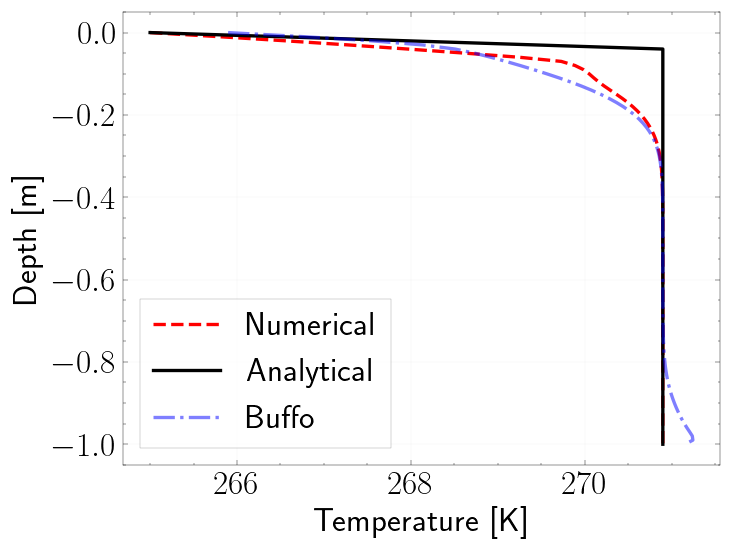

In [9]:
# run the model
results_data = SeaIceModel.get_results(preprocess_data, userinput_data)
analysis_data = Analysis.get_error_results(
            t_k_diff=results_data.t_k_diff,
            t_stefan_diff=results_data.t_stefan_diff,
            residual=results_data.residual_voller_all,
            temperature_mushy=results_data.t_k_iter_all,
            phi_mushy=results_data.all_phi_iter_all,
            salinity_mushy=results_data.s_k_iter_all,
            output_dir=out_dir_final,
        )

### Visualization of Model:
for more info on other visualization options look at:  [visualize model](https://starry-phoenix.github.io/spyice-thesis/build/html/api/spyice.postprocess.visualise_model.html)

In [10]:
model_visualization_object = VisualiseModel(
    user_input_dataclass=userinput_data,
    results_dataclass=results_data,
    error_analysis_dataclass=analysis_data,
)

Visualisation object created...


In [11]:
# Plots the Temperature Difference between Analytical and Numerical Solutions
model_visualization_object.plot_error_temp(100, norm="inf", savefig=False)


Plotting Temperature errors using inf norm...


In [12]:
# Plots the interface tracking over time for Analytical and Numerical Solutions
model_visualization_object.plot_depth_over_time(savefig=True)


Plotting Depth over time...
